In [1]:
!pip install --upgrade yfinance
from docplex.mp.model import Model
print("DOcplex loaded successfully!")


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
DOcplex loaded successfully!


In [2]:
import yfinance as yf
import pandas as pd

tickers=["HDFCBANK.NS", "ICICIBANK.NS", "TCS.NS", "INFY.NS", "HINDUNILVR.NS", "ITC.NS", "MARUTI.NS", "BAJAJ-AUTO.NS", "SUNPHARMA.NS", "DRREDDY.NS"]
data = yf.download(tickers, start="2020-1-1",end="2026-1-1")

prices = data["Close"]

print(prices.shape)
print(prices.head())
print(prices.isnull().sum())

[*********************100%***********************]  10 of 10 completed

(1487, 10)
Ticker      BAJAJ-AUTO.NS  DRREDDY.NS  HDFCBANK.NS  HINDUNILVR.NS  \
Date                                                                
2020-01-01    2636.314453  554.488342   605.529358    1749.931641   
2020-01-02    2611.960205  551.696045   609.389099    1751.286865   
2020-01-03    2570.994385  555.354919   600.698792    1741.708252   
2020-01-06    2542.204834  554.382446   587.698792    1730.864746   
2020-01-07    2542.456055  555.412720   597.004761    1735.608765   

Ticker      ICICIBANK.NS     INFY.NS      ITC.NS    MARUTI.NS  SUNPHARMA.NS  \
Date                                                                          
2020-01-01    519.137939  633.151184  173.395203  6945.335449    406.073975   
2020-01-02    522.861572  631.303772  174.669647  6962.575684    406.681732   
2020-01-03    521.169006  641.013367  173.686508  6890.763184    415.704651   
2020-01-06    508.450592  634.869568  171.210480  6689.528809    411.356842   
2020-01-07    505.742401  625.4

In [3]:
#saving data in csv for safety
prices.to_csv("raw_prices.csv")

train_prices=prices["2020-1-1":"2024-12-31"]
test_prices=prices["2025-1-1":"2025-12-31"]

train_prices.to_csv("train_prices.csv")
test_prices.to_csv("test_prices.csv")

print("Train_shape", train_prices.shape)
print("Test_shape", test_prices.shape)
train_prices.head()
test_prices.head()

Train_shape (1238, 10)
Test_shape (249, 10)


Ticker,BAJAJ-AUTO.NS,DRREDDY.NS,HDFCBANK.NS,HINDUNILVR.NS,ICICIBANK.NS,INFY.NS,ITC.NS,MARUTI.NS,SUNPHARMA.NS,TCS.NS
Date,,,,,,,,,,
2025-01-01,8524.504883,1360.372314,879.486938,2280.011475,1273.821167,1828.389893,441.214996,11088.287109,1860.379517,3903.252686
2025-01-02,8855.077148,1366.384277,884.913635,2327.042969,1280.717896,1901.574097,445.864594,11714.508789,1848.616577,3963.332764
2025-01-03,8744.090820,1344.125366,862.935669,2362.635986,1255.363525,1883.023071,439.072479,11806.463867,1820.710205,3891.341064
2025-01-06,8605.746094,1341.839844,843.843811,2333.130615,1254.420776,1882.149048,419.104309,11629.776367,1818.495361,3886.689941
2025-01-07,8592.531250,1343.032349,845.274414,2347.466309,1269.454834,1875.350220,417.636780,11595.793945,1824.401489,3823.383301


In [4]:
#calculating the return a particular stock gives each day
daily_returns=train_prices.pct_change()
daily_returns=daily_returns.dropna()

print(daily_returns.shape)
print(daily_returns.head())
print(daily_returns.describe())

(1237, 10)
Ticker      BAJAJ-AUTO.NS  DRREDDY.NS  HDFCBANK.NS  HINDUNILVR.NS  \
Date                                                                
2020-01-02      -0.009238   -0.005036     0.006374       0.000774   
2020-01-03      -0.015684    0.006632    -0.014261      -0.005469   
2020-01-06      -0.011198   -0.001751    -0.021641      -0.006226   
2020-01-07       0.000099    0.001858     0.015835       0.002741   
2020-01-08       0.007011    0.004524    -0.002618       0.004504   

Ticker      ICICIBANK.NS   INFY.NS    ITC.NS  MARUTI.NS  SUNPHARMA.NS  \
Date                                                                    
2020-01-02      0.007173 -0.002918  0.007350   0.002482      0.001497   
2020-01-03     -0.003237  0.015380 -0.005629  -0.010314      0.022187   
2020-01-06     -0.024404 -0.009585 -0.014256  -0.029203     -0.010459   
2020-01-07     -0.005326 -0.014820  0.001063   0.004430      0.014661   
2020-01-08      0.005833 -0.013326 -0.004886  -0.005429     -0.0141

In [5]:
#caluclating the expected return vector (mu)

# this code uses past data to mean in and treat it as yesterday's data
mu_stock= (daily_returns.mean())*252

#this code uses momentum means if a stock is running lately(for 125 days) it assumes that it will continue to do so..iloc is used b/c it gives latest momentum per stock
momentum_60d = train_prices.pct_change(125).iloc[-1]
#252/60 because 60days translated to a year long working days
momentum_annualized = momentum_60d * (252 / 125)

#momentum can be +ve or -ve..if mu nicely +ve then long it or if its too low then short it
mu=0.6*mu_stock+momentum_annualized*0.4
print(mu)


Ticker
BAJAJ-AUTO.NS    0.105302
DRREDDY.NS       0.210698
HDFCBANK.NS      0.099302
HINDUNILVR.NS    0.001062
ICICIBANK.NS     0.193791
INFY.NS          0.310222
ITC.NS           0.236931
MARUTI.NS        0.003958
SUNPHARMA.NS     0.402887
TCS.NS           0.135240
dtype: float64


In [6]:
#calculating variance and covariance also putting it into a covariance matrix
covariance_matrix=daily_returns.cov() * 252
print(covariance_matrix)

sigma=covariance_matrix.values

Ticker         BAJAJ-AUTO.NS  DRREDDY.NS  HDFCBANK.NS  HINDUNILVR.NS  \
Ticker                                                                 
BAJAJ-AUTO.NS       0.076668    0.016002     0.027592       0.019382   
DRREDDY.NS          0.016002    0.064850     0.010781       0.019105   
HDFCBANK.NS         0.027592    0.010781     0.074333       0.015873   
HINDUNILVR.NS       0.019382    0.019105     0.015873       0.057679   
ICICIBANK.NS        0.030800    0.013615     0.055342       0.019234   
INFY.NS             0.018742    0.019967     0.027166       0.022007   
ITC.NS              0.019531    0.012132     0.020475       0.018048   
MARUTI.NS           0.041049    0.015446     0.034219       0.023751   
SUNPHARMA.NS        0.020306    0.028946     0.018447       0.015292   
TCS.NS              0.018216    0.016111     0.020947       0.018745   

Ticker         ICICIBANK.NS   INFY.NS    ITC.NS  MARUTI.NS  SUNPHARMA.NS  \
Ticker                                                     

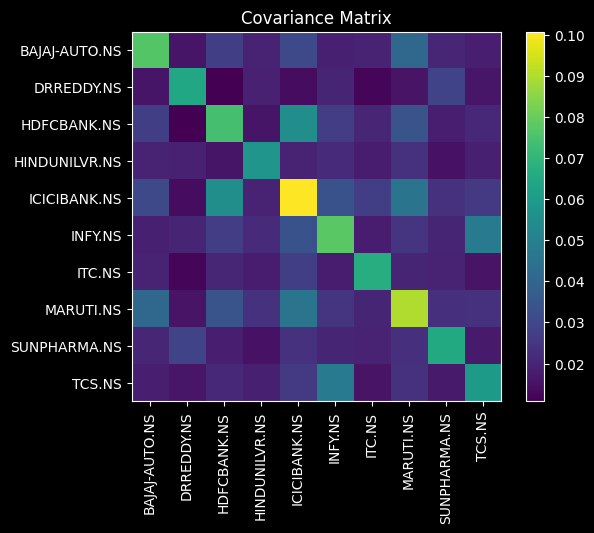

[0.29341368 0.08755275 0.0747595  0.01932507 0.06079619 0.05263622
 0.0428922  0.04089218 0.02969926 0.03233696]


In [7]:
import matplotlib.pyplot as plt
plt.figure()
plt.imshow(covariance_matrix)
plt.colorbar()
plt.title("Covariance Matrix")

plt.xticks(range(len(covariance_matrix.columns)), covariance_matrix.columns,rotation=90)
plt.yticks(range(len(covariance_matrix.index)), covariance_matrix.index)

plt.show()
#from the heatmap we can conclude that high covariance stocks have lighter color whereas dissimilar stocks have darker color
#the tcs and tcs covariance heatmap is showing lesser covariance color where as icici and icici covariance heatmap is showing higher covariance i.e yellow because Icici is more volatile in our dfataset and
#Variance = volatility²...Since covariance matrix is not normalized, magnitude differences reflect absolute risk levels rather than relative correlation.

#also need to check if covariance matrix is positive semi definitess: i.e if its eigenvalues(values in diagonal of a matrix) >=0
import numpy as np
eigenvalues=np.linalg.eigvals(covariance_matrix)
print(eigenvalues)

In [8]:
#basic markowitz algo
import numpy as np

def optimize_portfolio(
        mu,
        sigma,
        target_ret,
        max_weight=1.0,
        allow_short=True,
        short_lower_bound=-0.30,
        Total_marketexposure=1.5,
        prev_weights=None,
        lambda_tc=0.001,
        max_turnover=0.20,
        risk_free_rate=0.07, #assumed risk free return in India is around 7%
        #robust_delta=0.0 #here we have kept robust delta =0 that means this model is behaving just like basic markovitz theorem..we will call these later to compare basic markovitz to robust delta
):
    #inputs converted to numpy arrays for easy indexing
    mu=np.array(mu)
    sigma=np.array(sigma)
    n=len(mu)
    tickers=list(range(n))

    mdl=Model(name="Portfolio Optimizer")
#we want our model to look for highest optimization level
    mdl.parameters.optimalitytarget=3

#defining decision variables
    lb= short_lower_bound if allow_short else 0.0
    ub = max_weight
    w=mdl.continuous_var_list(n,lb=lb,ub=ub,name="w")

#for shorting:making difference between longing and shorting bigger to reduce leverage and risks..that means if we long Rs.10 then we optimizer can't short for Rs.10 to increase invested amount which increases leverage
    if allow_short:
        g=mdl.continuous_var_list(n,lb=0,name="g")
        for i in tickers:
            mdl.add_constraint(g[i]>=w[i])
            mdl.add_constraint(g[i]>=-w[i])
        mdl.add_constraint(mdl.sum(g[i] for i in tickers)<=Total_marketexposure)

    #quadratic objective: min. variance = min. risk
    portfolio_variance=mdl.sum(
        sigma[i][j]*w[i]*w[j]
        for i in tickers
        for j in tickers
    )

    if prev_weights is not None:
        prev_weights=np.array(prev_weights)
        t=mdl.continuous_var_list(n,lb=0,name="t")
        for i in tickers:
            mdl.add_constraint(t[i]>=(w[i]-prev_weights[i]))
            mdl.add_constraint(t[i]>=-(w[i]-prev_weights[i]))
        mdl.add_constraint(mdl.sum(t)<=max_turnover)
        tc_penalty=lambda_tc*mdl.sum(t)
    else:
        tc_penalty=0

    mdl.minimize(portfolio_variance + tc_penalty)
    #add constraints

    #fully invested
    mdl.add_constraint(mdl.sum(w[i] for i in tickers)==1)

    #target return constraint
    mdl.add_constraint(
    mdl.sum(mu[i] * w[i] for i in tickers) >= target_ret
    )
    #solve the model
    solution=mdl.solve()
    if solution is None:
        print("no feasible solution")
        return None

    #postprocessing
    weights=np.array([w[i].solution_value for i in tickers])
    portfolio_return=float(np.dot(mu,weights))
    portfolio_variance=float(weights @ sigma @ weights)
    portfolio_risk=float(np.sqrt(portfolio_variance))
    if portfolio_risk > 0:
        sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_risk
    else:
        sharpe_ratio = 0


    return {
    "weights": weights,
    "portfolio_return": portfolio_return,
    "portfolio_risk": portfolio_risk,
    "portfolio_variance": portfolio_variance,
    "sharpe_ratio": sharpe_ratio
}

In [9]:
# 1. Define a target return (e.g., 15% annualized)
target_ret = 0.25

# 2. Call the optimizer!
# We pass mu.values because mu is currently a pandas Series
results = optimize_portfolio(
    mu=mu.values,
    sigma=sigma,
    target_ret=target_ret,
    allow_short=True,
    max_weight=1.00
)

# 3. Print the results clearly
if results:
    print("=== OPTIMIZATION SUCCESSFUL ===\n")
    print(f"Expected Annual Return: {results['portfolio_return']:.2%}")
    print(f"Portfolio Risk (Vol):   {results['portfolio_risk']:.2%}")
    print(f"Sharpe Ratio:           {results['sharpe_ratio']:.2f}\n")

    print("=== OPTIMAL WEIGHTS ===")
    # Pair the actual stock tickers with their calculated weights
    for stock, weight in zip(tickers, results['weights']):
        # Only print weights that are mathematically significant (ignore tiny floating point noise)
        if abs(weight) > 0.001:
            print(f"{stock}: {weight:.2%}")

=== OPTIMIZATION SUCCESSFUL ===

Expected Annual Return: 25.00%
Portfolio Risk (Vol):   16.63%
Sharpe Ratio:           1.08

=== OPTIMAL WEIGHTS ===
HDFCBANK.NS: 8.61%
ICICIBANK.NS: 15.64%
TCS.NS: 8.07%
INFY.NS: 6.59%
ITC.NS: 12.15%
MARUTI.NS: 20.06%
BAJAJ-AUTO.NS: -5.33%
SUNPHARMA.NS: 25.64%
DRREDDY.NS: 8.61%


In [10]:
result = optimize_portfolio(
    mu= mu.values,
    sigma = sigma,
    target_ret= 0.25,
    max_weight = 0.20,#max percentage of portfolio a stock can take is 20%
    allow_short = True
)

if result:
    print("=== OPTIMIZATION SUCCESSFUL ===\n")
    print(f"Expected Annual Return: {result['portfolio_return']:.2%}")
    print(f"Portfolio Risk (Vol):   {result['portfolio_risk']:.2%}")
    print(f"Sharpe Ratio:           {result['sharpe_ratio']:.2f}\n")

    print("=== OPTIMAL WEIGHTS ===")

    for stock, weight in zip(tickers, result['weights']):
        if abs(weight) > 0.001:
            print(f"{stock}: {weight:.2%}")

=== OPTIMIZATION SUCCESSFUL ===

Expected Annual Return: 25.00%
Portfolio Risk (Vol):   16.71%
Sharpe Ratio:           1.08

=== OPTIMAL WEIGHTS ===
HDFCBANK.NS: 9.74%
ICICIBANK.NS: 19.47%
TCS.NS: 7.46%
INFY.NS: 4.59%
HINDUNILVR.NS: 1.74%
ITC.NS: 16.34%
MARUTI.NS: 20.00%
BAJAJ-AUTO.NS: -6.36%
SUNPHARMA.NS: 20.00%
DRREDDY.NS: 7.03%


In [11]:
def robust_delta(
        mu,
        sigma,
        target_ret,
        max_weight=1.0,
        allow_short=True,
        short_lower_bound=-0.30,
        Total_marketexposure=1.5,
        prev_weights=None,
        lambda_tc=0.001,
        max_turnover=0.20,
        risk_free_rate=0.07,
        robust_delta=0.15
):
    #inputs converted to numpy arrays for easy indexing
    mu=np.array(mu)
    sigma=np.array(sigma)
    n=len(mu)
    tickers=list(range(n))

    mdl=Model(name="Portfolio Optimizer")
#we want our model to look for highest optimization level
    mdl.parameters.optimalitytarget=3

#defining decision variables
    lb= short_lower_bound if allow_short else 0.0
    ub = max_weight
    w=mdl.continuous_var_list(n,lb=lb,ub=ub,name="w")

#for shorting:making difference between longing and shorting bigger to reduce leverage and risks..that means if we long Rs.10 then we optimizer can't short for Rs.10 to increase invested amount which increases leverage
    if allow_short:
        g=mdl.continuous_var_list(n,lb=0,name="g")
        for i in tickers:
            mdl.add_constraint(g[i]>=w[i])
            mdl.add_constraint(g[i]>=-w[i])
        mdl.add_constraint(mdl.sum(g[i] for i in tickers)<=Total_marketexposure)

    #quadratic objective: min. variance = min. risk
    portfolio_variance=mdl.sum(
        sigma[i][j]*w[i]*w[j]
        for i in tickers
        for j in tickers
    )

    if prev_weights is not None:
        prev_weights=np.array(prev_weights)
        t=mdl.continuous_var_list(n,lb=0,name="t")
        for i in tickers:
            mdl.add_constraint(t[i]>=(w[i]-prev_weights[i]))
            mdl.add_constraint(t[i]>=-(w[i]-prev_weights[i]))
        mdl.add_constraint(mdl.sum(t)<=max_turnover)
        tc_penalty=lambda_tc*mdl.sum(t)
    else:
        tc_penalty=0

    mdl.minimize(portfolio_variance + tc_penalty)
    #add constraints

    #fully invested
    mdl.add_constraint(mdl.sum(w[i] for i in tickers)==1)

    #robust model
    #Robust return constraint: penalise uncertain returns by subtracting delta * volatility
    # This makes the optimizer more conservative — it assumes each stock's return could be delta standard deviations lower than estimated.
    std_i = np.sqrt(np.diag(sigma))

    if robust_delta>0:
        effective_mu=mu-robust_delta*std_i #pessimistic expected return if risk or volatility(std) is high then robust_delta is >0
    else:
        effective_mu=mu #same as basic markowitz
    #target return constraint
    mdl.add_constraint(
    mdl.sum(effective_mu[i] * w[i] for i in tickers) >= target_ret
    )
    #solve the model
    solution=mdl.solve()
    if solution is None:
        print("no feasible solution")
        return None

    #postprocessing
    weights=np.array([w[i].solution_value for i in tickers])
    portfolio_return=float(np.dot(mu,weights))
    portfolio_variance=float(weights @ sigma @ weights)
    portfolio_risk=float(np.sqrt(portfolio_variance))
    if portfolio_risk > 0:
        sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_risk
    else:
        sharpe_ratio = 0


    return {
    "weights": weights,
    "portfolio_return": portfolio_return,
    "portfolio_risk": portfolio_risk,
    "portfolio_variance": portfolio_variance,
    "sharpe_ratio": sharpe_ratio
}

In [12]:

#CVaR(Conditional Value at Risk)
def solve_cvar(mu,sigma,target_ret,scenarios,cvar_alpha,allow_short,short_lower_bound,Total_marketexposure,max_weight,risk_free_rate):

    mu=np.array(mu)
    sigma=np.array(sigma)
    
    n=len(mu)
    tickers=list(range(n))
    S=scenarios.shape[0]
    R=scenarios.values

    mdl=Model(name="CVaR_Optimizer")

    lb=short_lower_bound if allow_short else 0.0
    w=mdl.continuous_var_list(n,lb=lb,ub=max_weight,name="w")

    #defining var - loss that we can suffer
    var_threshold=mdl.continuous_var(lb=-1.0,ub=1.0,name="VaR")
    #defining z - excess loss beyond VaR
    z=mdl.continuous_var_list(S,lb=0,name="z")

    #gross exposure
    if allow_short:
        g=mdl.continuous_var_list(n,lb=0,name="g")
        for i in tickers:
            mdl.add_constraint(g[i]>=w[i])
            mdl.add_constraint(g[i]>=-w[i])
        mdl.add_constraint(mdl.sum(g[i] for i in tickers)<=Total_marketexposure)

    #cvar objective function
    scale=1.0/(cvar_alpha*S) #cvar_alpha=let 0.05 is the % of worst case scenario we're focusing on
    mdl.minimize(var_threshold+scale*mdl.sum(z))
    #var_threshold means baseline worst case that we can handle
    #scale*sum(z) means loss beyond var that is too much to handle

    #scenario-wise constraints scenario can be each trading day
    for s in range(S):
        portfolio_return_s=mdl.sum(w[i]*float(R[s,i])for i in tickers)
        mdl.add_constraint(z[s]>=-portfolio_return_s-var_threshold)

    #constraints
    mdl.add_constraint(mdl.sum(w)==1)
    mdl.add_constraint(mdl.sum(mu[i]*w[i] for i in tickers)>=target_ret)

    #solve
    solution=mdl.solve(log_output=False)
    if solution is None:
        print("no feasible solution")
        return None

    #extracting values
    weights=np.array([w[i].solution_value for i in tickers])
    cvar_value=solution.get_objective_value()
    port_return=float(np.dot(mu,weights))
    port_risk=float(np.sqrt(weights @ sigma @ weights))
    sharpe=(port_return-risk_free_rate)/port_risk

    return {
        "weights": weights,
        "portfolio_return": port_return,
        "portfolio_risk": port_risk,
        "sharpe_ratio": sharpe,
        "portfolio_variance":port_risk**2,
        "cvar": cvar_value
    }




In [13]:
#basic markovitz
res_basic = optimize_portfolio(
    mu=mu.values,
    sigma=sigma,
    target_ret=0.20,
)

#robust delta(mild)
res_robust_1 = robust_delta(
    mu=mu.values,
    sigma=sigma,
    target_ret=0.20,
    robust_delta=0.05
)
#robust delta(strong)
res_robust_2 = robust_delta(
    mu=mu.values,
    sigma=sigma,
    target_ret=0.20,
    robust_delta=0.15
)
res_robust_3 = robust_delta(
    mu=mu.values,
    sigma=sigma,
    target_ret=0.20,
    robust_delta=0.25
)
res_robust_4 = robust_delta(
    mu=mu.values,
    sigma=sigma,
    target_ret=0.20,
    robust_delta=0.30
)
res_robust_5 = robust_delta(
    mu=mu.values,
    sigma=sigma,
    target_ret=0.20,
    robust_delta=0.40
)
res_robust_6 = robust_delta(
    mu=mu.values,
    sigma=sigma,
    target_ret=0.20,
    robust_delta=0.55
)
res_robust_7 = robust_delta(
    mu=mu.values,
    sigma=sigma,
    target_ret=0.20,
    robust_delta=0.65
)
res_robust_8 = robust_delta(
    mu=mu.values,
    sigma=sigma,
    target_ret=0.20,
    robust_delta=0.75
)
res_robust_9 = robust_delta(
    mu=mu.values,
    sigma=sigma,
    target_ret=0.20,
    robust_delta=0.85
)

res_robust_10= robust_delta(
    mu=mu.values,
    sigma=sigma,
    target_ret=0.20,
    robust_delta=1.00
)
res_robust_11 = robust_delta(
    mu=mu.values,
    sigma=sigma,
    target_ret=0.20,
    robust_delta=1.10
)



#this is free cplex so only 1000 constraints and 1000 avriables:(
#in cvar we run scenarios(every workingday return stock) so for 2020-2024 = 1238 variables(got shape from data),then 10 from gross exposure,then 10 from weights,then 1 from var_threshold.
#Total variables = 1259
#again 1238 constraints,gross exposure 2*10=20,toatlmarketexpo=1,constraints=2
#total constraints=1261
#so we set scenarios to be 800
cvar_scenarios = daily_returns.sample(n=800, random_state=42)
#cvar
res_cvar = solve_cvar(
    mu=mu.values,
    sigma=sigma,
    target_ret=0.20,
    scenarios=cvar_scenarios,
    cvar_alpha=0.05,
    allow_short=True,
    short_lower_bound=-0.30,
    Total_marketexposure=1.5,
    max_weight=1.0,
    risk_free_rate=0.07
)

# ── Comparison ───────────────────────────────────────────────────────────────
print(f"{'Method':<20} | {'Return':>8} | {'Risk':>8} | {'Sharpe':>8}")
print("-" * 55)
print(f"{'Basic Markowitz':<20} | {res_basic['portfolio_return']:>8.2%} | {res_basic['portfolio_risk']:>8.2%} | {res_basic['sharpe_ratio']:>8.2f}")
print(f"{'Robust delta=0.05':<20} | {res_robust_1['portfolio_return']:>8.2%} | {res_robust_1['portfolio_risk']:>8.2%} | {res_robust_1['sharpe_ratio']:>8.2f}")
print(f"{'Robust delta=0.15':<20} | {res_robust_2['portfolio_return']:>8.2%} | {res_robust_2['portfolio_risk']:>8.2%} | {res_robust_2['sharpe_ratio']:>8.2f}")
print(f"{'Robust delta=0.20':<20} | {res_robust_3['portfolio_return']:>8.2%} | {res_robust_3['portfolio_risk']:>8.2%} | {res_robust_3['sharpe_ratio']:>8.2f}")
print(f"{'Robust delta=0.30':<20} | {res_robust_4['portfolio_return']:>8.2%} | {res_robust_4['portfolio_risk']:>8.2%} | {res_robust_4['sharpe_ratio']:>8.2f}")
print(f"{'Robust delta=0.40':<20} | {res_robust_5['portfolio_return']:>8.2%} | {res_robust_5['portfolio_risk']:>8.2%} | {res_robust_5['sharpe_ratio']:>8.2f}")
print(f"{'Robust delta=0.55':<20} | {res_robust_6['portfolio_return']:>8.2%} | {res_robust_6['portfolio_risk']:>8.2%} | {res_robust_6['sharpe_ratio']:>8.2f}")
print(f"{'Robust delta=0.65':<20} | {res_robust_7['portfolio_return']:>8.2%} | {res_robust_7['portfolio_risk']:>8.2%} | {res_robust_7['sharpe_ratio']:>8.2f}")
print(f"{'Robust delta=0.75':<20} | {res_robust_8['portfolio_return']:>8.2%} | {res_robust_8['portfolio_risk']:>8.2%} | {res_robust_8['sharpe_ratio']:>8.2f}")
print(f"{'Robust delta=0.85':<20} | {res_robust_9['portfolio_return']:>8.2%} | {res_robust_9['portfolio_risk']:>8.2%} | {res_robust_9['sharpe_ratio']:>8.2f}")
print(f"{'Robust delta=1.00':<20} | {res_robust_10['portfolio_return']:>8.2%} | {res_robust_10['portfolio_risk']:>8.2%} | {res_robust_10['sharpe_ratio']:>8.2f}")
print(f"{'Robust delta=1.10':<20} | {res_robust_11['portfolio_return']:>8.2%} | {res_robust_11['portfolio_risk']:>8.2%} | {res_robust_11['sharpe_ratio']:>8.2f}")
print(f"{'CVaR 5%':<20} | {res_cvar['portfolio_return']:>8.2%} | {res_cvar['portfolio_risk']:>8.2%} | {res_cvar['sharpe_ratio']:>8.2f}")

#comparison
print("Basic:", res_basic["portfolio_return"], res_basic["portfolio_risk"])
print("Robust 0.05:", res_robust_1["portfolio_return"], res_robust_1["portfolio_risk"])
print("Robust 0.15:", res_robust_2["portfolio_return"], res_robust_2["portfolio_risk"])

#results here robust_delta=0.85 gives the highest sharpe ratio optimal zone risk less compared to high returns

Method               |   Return |     Risk |   Sharpe
-------------------------------------------------------
Basic Markowitz      |   20.00% |   15.96% |     0.81
Robust delta=0.05    |   21.28% |   16.09% |     0.89
Robust delta=0.15    |   23.85% |   16.44% |     1.03
Robust delta=0.20    |   26.44% |   16.90% |     1.15
Robust delta=0.30    |   27.74% |   17.18% |     1.21
Robust delta=0.40    |   30.33% |   17.81% |     1.31
Robust delta=0.55    |   34.23% |   18.95% |     1.44
Robust delta=0.65    |   36.82% |   19.81% |     1.51
Robust delta=0.75    |   39.31% |   20.76% |     1.56
Robust delta=0.85    |   41.74% |   21.89% |     1.59
Robust delta=1.00    |   45.17% |   24.15% |     1.58
Robust delta=1.10    |   47.54% |   26.33% |     1.54
CVaR 5%              |   20.00% |   16.75% |     0.78
Basic: 0.20000000000000004 0.15963738729745022
Robust 0.05: 0.21280248571203184 0.16089836412838604
Robust 0.15: 0.23853419096776213 0.16436166445640438


Model                | Train Ret | Test Ret | Test Risk | Sharpe |   Max DD
────────────────────────────────────────────────────────────────────────
Basic Markowitz      |    20.00% |   -4.95% |    10.90% |  -1.10 |  -14.18%
Robust δ=0.05        |    21.28% |   -5.60% |    11.05% |  -1.14 |  -14.51%
Robust δ=0.15        |    23.85% |   -6.96% |    11.44% |  -1.22 |  -15.25%
Robust δ=0.85        |    41.74% |  -18.48% |    16.32% |  -1.56 |  -24.58%
CVaR 5%              |    20.00% |   -8.58% |    11.61% |  -1.34 |  -14.08%


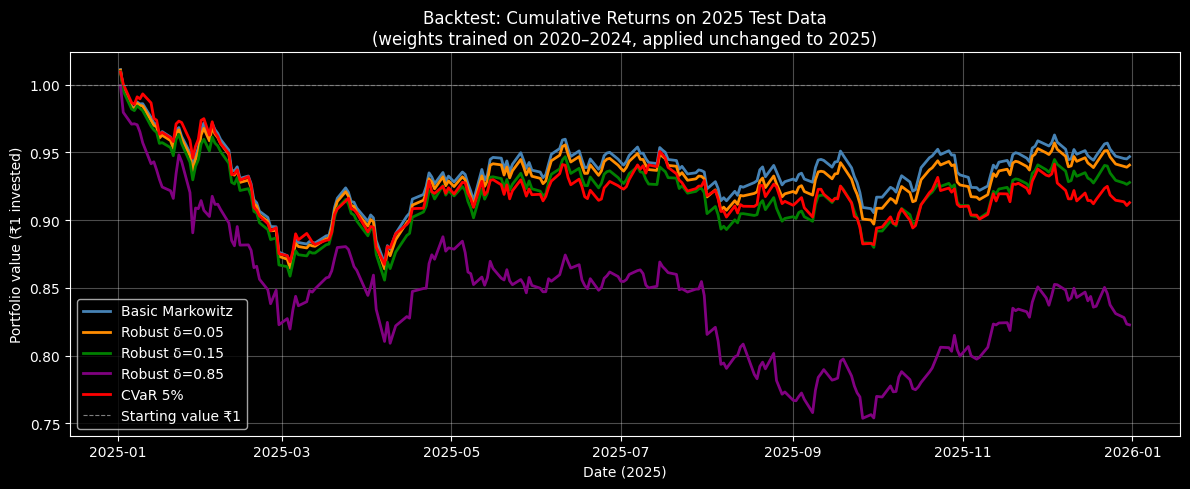

In [14]:
stock_names = list(covariance_matrix.columns)

all_models = {
    "Basic Markowitz": res_basic,
    "Robust δ=0.05" : res_robust_1,
    "Robust δ=0.15": res_robust_2,
    "Robust δ=0.85" : res_robust_9,
    "CVaR 5%"   : res_cvar,
}
colors = ["steelblue", "darkorange", "green", "purple", "red"]
#to get %returns
test_returns = test_prices.pct_change().dropna()

def maxpeak_toughloss(cumulative_returns):
    highest_peak=cumulative_returns.cummax()
    drawdown=(cumulative_returns-highest_peak)/highest_peak
    return drawdown.min()
print(f"{'Model':<20} | {'Train Ret':>9} | {'Test Ret':>8} | {'Test Risk':>9} | {'Sharpe':>6} | {'Max DD':>8}")
print("─" * 72)
stored={}
for(name,res),color in zip(all_models.items(),colors):
    w=res["weights"]
    port_daily=test_returns.values @ w
    cum_net=pd.Series((1+port_daily).cumprod(),index=test_returns.index)
    stored[name]=(color,cum_net)
    test_ret=port_daily.mean()*252
    test_risk=port_daily.std()*np.sqrt(252)
    #riskfreereturn in India taken as 0.07
    sharpe=(test_ret-0.07)/test_risk
    maxdd=maxpeak_toughloss(cum_net)

    print(f"{name:<20} | {res['portfolio_return']:>9.2%} | {test_ret:>8.2%} | "
          f"{test_risk:>9.2%} | {sharpe:>6.2f} | {maxdd:>8.2%}")

fig, ax = plt.subplots(figsize=(12, 5))

for name, (color, cum_ret) in stored.items():
    ax.plot(cum_ret.index, cum_ret.values, label=name, color=color, linewidth=2)

ax.axhline(1.0, color="gray", linestyle="--", linewidth=0.8, label="Starting value ₹1")
ax.set_xlabel("Date (2025)")
ax.set_ylabel("Portfolio value (₹1 invested)")
ax.set_title("Backtest: Cumulative Returns on 2025 Test Data\n"
             "(weights trained on 2020–2024, applied unchanged to 2025)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()
#chart


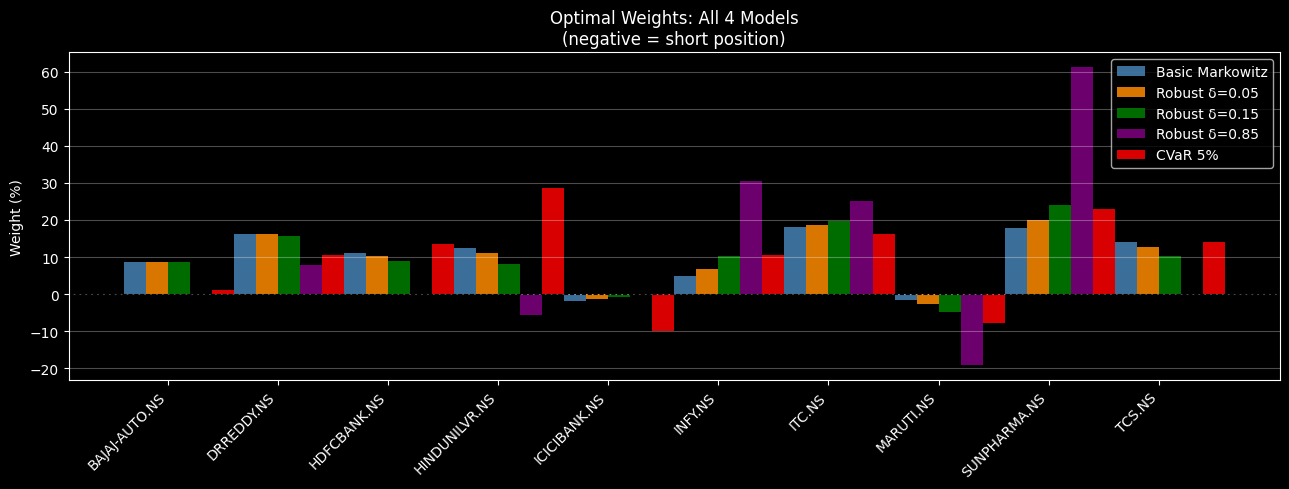

In [15]:
x     = np.arange(len(stock_names))
width = 0.2

fig, ax = plt.subplots(figsize=(13, 5))

for i, ((name, res), color) in enumerate(zip(all_models.items(), colors)):
    ax.bar(x + i * width, res["weights"] * 100,
           width, label=name, color=color, alpha=0.85)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(stock_names, rotation=45, ha="right")
ax.set_ylabel("Weight (%)")
ax.set_title("Optimal Weights: All 4 Models\n(negative = short position)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

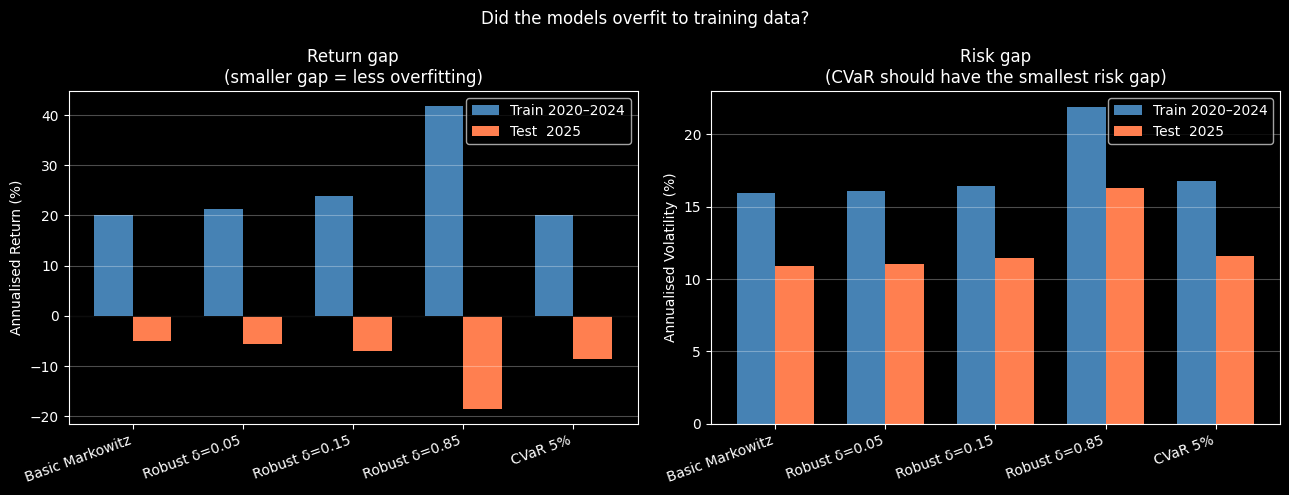

In [16]:
names      = list(all_models.keys())
train_rets = [r["portfolio_return"] * 100 for r in all_models.values()]
test_rets, test_risks = [], []

for res in all_models.values():
    pd_daily = test_returns.values @ res["weights"]
    test_rets.append(pd_daily.mean()  * 252 * 100)
    test_risks.append(pd_daily.std()  * np.sqrt(252) * 100)

x, bw = np.arange(len(names)), 0.35
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: return gap
axes[0].bar(x - bw/2, train_rets, bw, label="Train 2020–2024", color="steelblue")
axes[0].bar(x + bw/2, test_rets,  bw, label="Test  2025",      color="coral")
axes[0].set_xticks(x); axes[0].set_xticklabels(names, rotation=20, ha="right")
axes[0].set_ylabel("Annualised Return (%)")
axes[0].set_title("Return gap\n(smaller gap = less overfitting)")
axes[0].axhline(0, color="black", linewidth=0.6)
axes[0].legend(); axes[0].grid(axis="y", alpha=0.3)

# Right: risk gap
train_risks = [r["portfolio_risk"] * 100 for r in all_models.values()]
axes[1].bar(x - bw/2, train_risks, bw, label="Train 2020–2024", color="steelblue")
axes[1].bar(x + bw/2, test_risks,  bw, label="Test  2025",      color="coral")
axes[1].set_xticks(x); axes[1].set_xticklabels(names, rotation=20, ha="right")
axes[1].set_ylabel("Annualised Volatility (%)")
axes[1].set_title("Risk gap\n(CVaR should have the smallest risk gap)")
axes[1].legend(); axes[1].grid(axis="y", alpha=0.3)

plt.suptitle("Did the models overfit to training data?", fontsize=12)
plt.tight_layout()
plt.show()